# Clustering Comparison: Wine Dataset

Dataset: [`harrywang/wine-dataset-for-clustering`](https://www.kaggle.com/datasets/harrywang/wine-dataset-for-clustering)
(178 samples, 13 continuous chemical properties). Ground truth is the 3 wine cultivars
from `sklearn.datasets.load_wine()`.

Six clustering algorithms are compared with internal metrics (silhouette, Davies-Bouldin)
and an external metric (ARI vs. the true cultivars).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sc4020 import data, clustering, metrics, viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
RESULTS_DIR = Path("..") / "results"

METRIC_COLS = [
    "method", "fit_seconds", "n_clusters_found", "noise_points",
    "silhouette", "davies_bouldin", "adjusted_rand_index",
]

## Load and standardize

In [2]:
ds = data.load_wine_data()
print(f"{ds.name}: X={ds.X.shape}, classes={ds.class_names}, n_true_clusters={ds.n_true_clusters}")

wine: X=(178, 13), classes=[np.str_('class_0'), np.str_('class_1'), np.str_('class_2')], n_true_clusters=3


## 2D embedding for visualization

Clustering runs on the full standardized 13-D space; PCA to 2D is *only* used to plot.

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(ds.X)
var_ratio = pca.explained_variance_ratio_ * 100

## Fit 6 clustering models

* **Distance-based:** K-Means (k=3)
* **Hierarchical:** Agglomerative (k=3, Ward linkage)
* **Probabilistic:** Gaussian Mixture (k=3)
* **Graph-based:** Spectral (k=3, nearest-neighbors affinity)
* **Density-based:** DBSCAN (eps=2.3, min_samples=4)
* **Exemplar-based:** Affinity Propagation (damping=0.8)

In [4]:
results = clustering.run_models(clustering.wine_models(), ds.X)
for name, r in results.items():
    print(f"{name:22s} fit_seconds={r.fit_seconds:.3f}")

K-Means (k=3)          fit_seconds=1.329
Agglomerative (k=3)    fit_seconds=0.021
GMM (k=3)              fit_seconds=0.005
Spectral (k=3)         fit_seconds=0.021
DBSCAN (eps=2.3)       fit_seconds=0.002
Affinity Propagation   fit_seconds=0.006


## Metrics

In [5]:
results_df = metrics.build_results_table(ds.name, ds.X, results, ds.y)
display(results_df[METRIC_COLS].round(4))
results_df.to_csv(RESULTS_DIR / "wine_results.csv", index=False)

,method,fit_seconds,n_clusters_found,noise_points,silhouette,davies_bouldin,adjusted_rand_index
0,K-Means (k=3),1.3286,3,0,0.2849,1.3892,0.8975
1,Agglomerative (k=3),0.0211,3,0,0.2774,1.4186,0.7899
2,GMM (k=3),0.0046,3,0,0.2849,1.3892,0.8975
3,Spectral (k=3),0.0211,3,0,0.2828,1.3907,0.8804
4,DBSCAN (eps=2.3),0.0015,2,36,0.3254,1.1979,0.4100
5,Affinity Propagation,0.0062,15,0,0.1199,1.6384,0.2449


## Cluster visualizations vs. ground truth

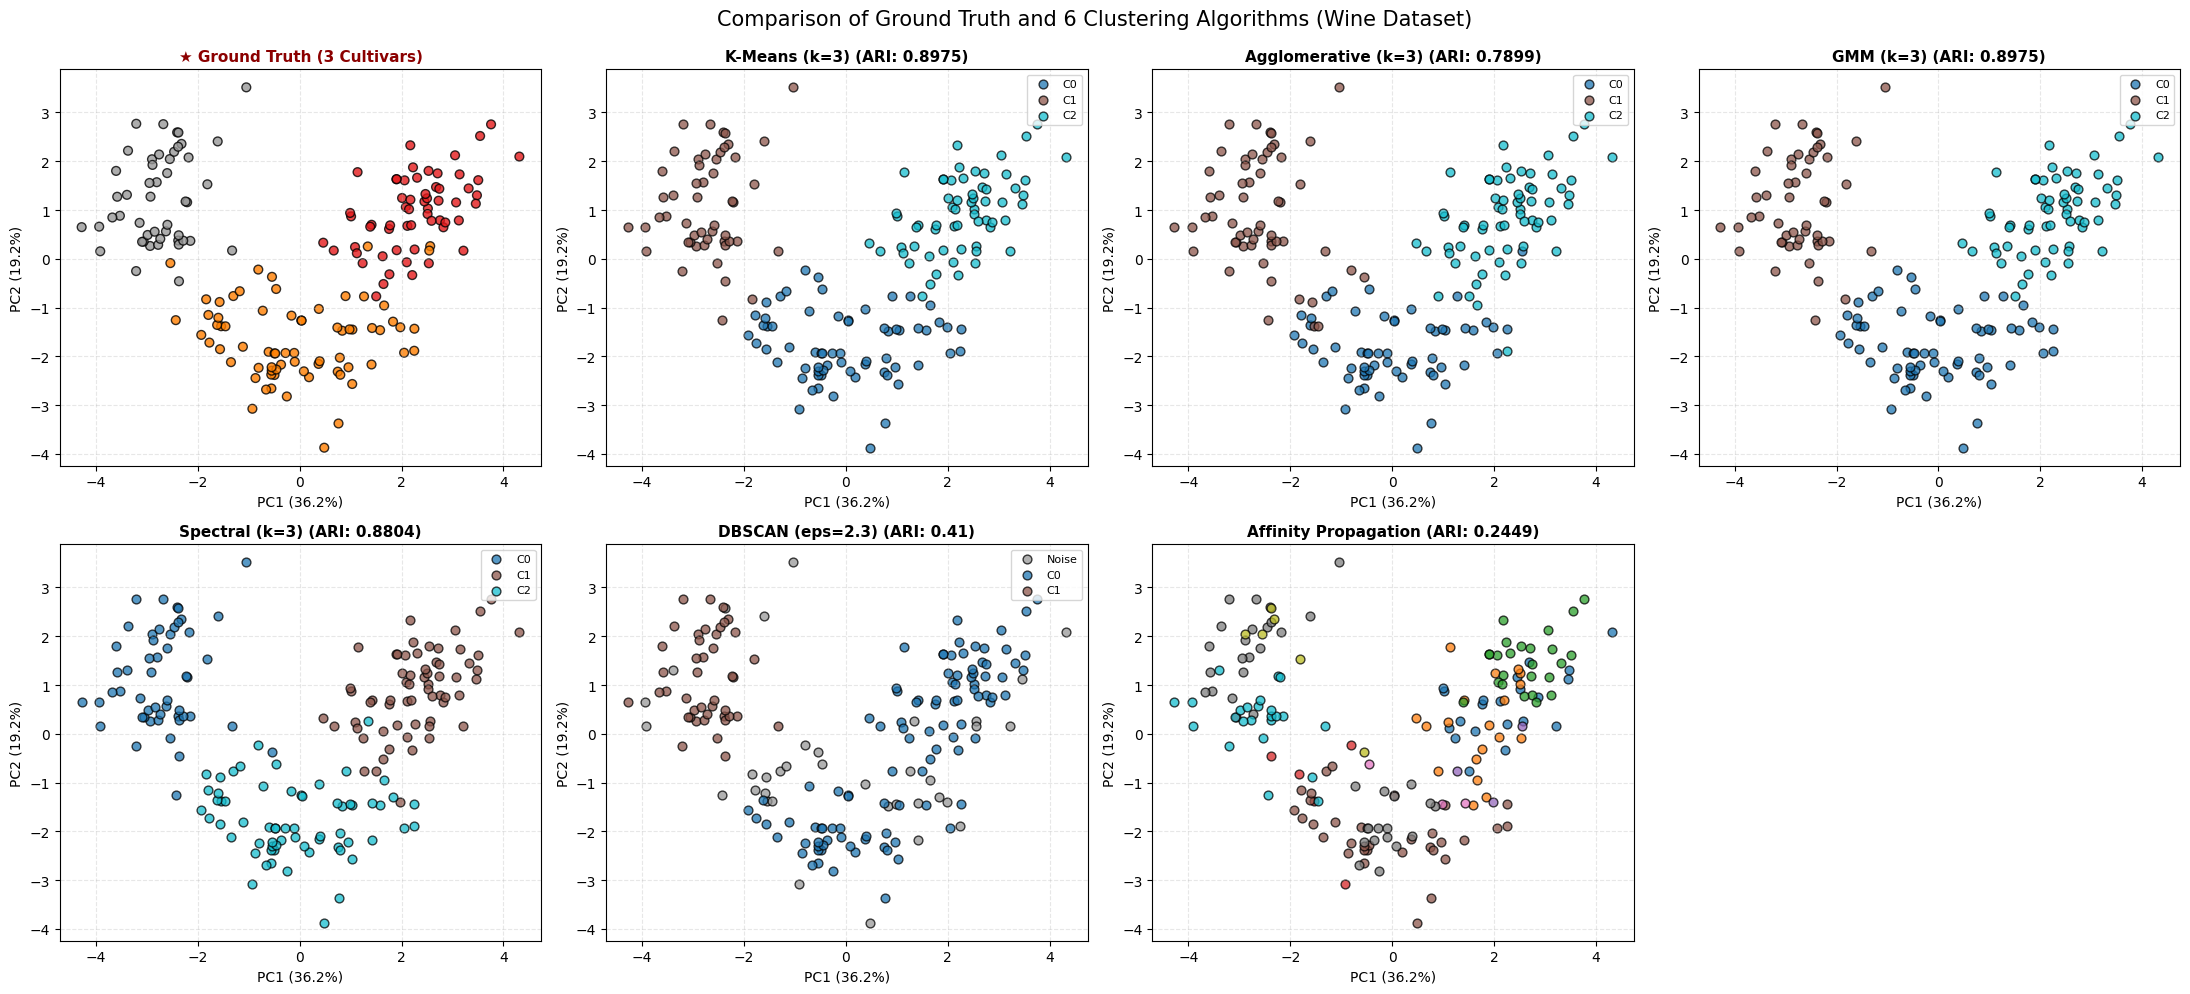

In [6]:
ari = dict(zip(results_df["method"], results_df["adjusted_rand_index"].round(4)))
viz.plot_pca_grid(
    X_2d, results, y_true=ds.y, var_ratio=var_ratio, ari=ari,
    gt_title="★ Ground Truth (3 Cultivars)",
    title="Comparison of Ground Truth and 6 Clustering Algorithms (Wine Dataset)",
    gt_cmap="Set1", edgecolors="k", size=40,
)
plt.show()

## Discussion

* **Top performers (K-Means & GMM):** standardized chemical properties form three convex,
  globular clusters, so both recover the cultivars almost perfectly (ARI ≈ 0.8975).
* **DBSCAN limitation:** there is no strict density gap between cultivars. A single global
  radius ε merges adjacent cultivars while treating peripheral samples as noise.
* **Affinity Propagation over-segmentation:** with no cluster-count constraint, message
  passing splits the 3 cultivars into many micro-clusters.